# CVE to CWE Mapping

## Pre reqs:
You need to have ran scrape_cwe.ipynb file and fill the CVE folder in scrapers/scraped_data in order to continue

### Requirements

In [1]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu 
%pip install sentence-transformers pandas tqdm matplotlib

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 9.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 12.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 8.6 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers━━━━━━━━━━━━━━ 0/3 [huggingface-hub]
    Found existing installation: tokenizers 0.22.20/3 [huggingface-hub]
    Uninstalling tokenizers-0.22.2:━━━━━━━━━ 0/3 [huggingface-hub]
      Successfully uninstalled tokenizers-0.22.2 0/3 [huggingface-hub]
  Attempting uninstall: transformers━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [tokenizers]
    Found existing installation: transformers 4.56.2━━━━━━━━━━ 1/3 [tokeniz

In [1]:
import json
import re
 
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
from tqdm import tqdm

/home/regularpooria/Projects/CWE_CVE_Mapping/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W1002 11:44:00.345000 59008 site-packages/torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W1002 11:44:00.401000 59008 site-packages/torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


## Loading scraped data

In [2]:
# BASE_DIR = "./CWE_CVE_Mapping" # Kaggle
BASE_DIR = "../" # Local

### Loading CWE

In [3]:
with open(f"{BASE_DIR}/scrapers/scraped_data/CWE_SOFTWARE.json", "r", encoding="utf-8") as f:
    CWE = json.load(f)

### Loading CVE

In [4]:
CVE_files = ["nvd_2025_cwe699.csv"]

CVE: pd.DataFrame = pd.DataFrame()
for i, file in enumerate(CVE_files):
    if i == 0:
        CVE = pd.read_csv(f"{BASE_DIR}/scrapers/scraped_data/CVE/{file}")
        continue
    
    CVE = pd.concat([CVE, pd.read_csv(f"{BASE_DIR}/scrapers/scraped_data/CVE/{file}")], ignore_index=True)

## CWE graph (root -> category -> child)
Used for children lookup and for finding the parent categories of a ground-truth CWE.
 

In [5]:
def make_graph(CWE):
    G = nx.DiGraph()
    G.add_node("root", type="main")
    for cat_id, category in CWE.items():
        G.add_node(cat_id, type="category", title=category["title"])
        G.add_edge("root", cat_id)
        for child_id, child in category["children"].items():
            if not G.has_node(child_id):  # a child can belong to several categories
                G.add_node(child_id, type="child", title=child["title"])
            G.add_edge(cat_id, child_id)
    return G

In [6]:
graph = make_graph(CWE)
 
category_ids = list(CWE.keys())
child_ids = [n for n, d in graph.nodes(data=True) if d["type"] == "child"]
child_pos = {cid: i for i, cid in enumerate(child_ids)}  # child id -> row in child matrix
 
# children (as row indices into the child matrix) for every category
category_child_rows = [
    [child_pos[c] for c in graph.successors(cat_id)] for cat_id in category_ids
]
 
 
def parents_of(child_id):
    return [p for p in graph.predecessors(child_id) if p != "root"]
 

## Embedding

In [10]:
embedding_model = SentenceTransformer("./all_minilm_l6_v2_finetune_16bit", model_kwargs={"torch_dtype": torch.float32})

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights: 100%|██████████| 74/74 [00:00<00:00, 5797.78it/s]


In [11]:
# CWE Embeddings - Slower because not batching but it's more readable

def extract_description(child):
    description = child["description"]
    if child["extended_description"] is not None:
        extended = child["extended_description"]
        description += f"\n{extended}"
    return description

child_lookup = {}
for category in CWE.values():
    for child_id, child in category["children"].items():
        child_lookup.setdefault(child_id, child)
 
child_embeddings = embedding_model.encode(
    [extract_description(child_lookup[cid]) for cid in child_ids],
    batch_size=64,
    show_progress_bar=True,
    convert_to_tensor=True,
)

category_embeddings = []
for cat_id in tqdm(category_ids):
    category = CWE[cat_id]
    child_titles = [child["title"] for child in category["children"].values()]
    text = category["title"] + ",".join(child_titles) + category["summary"]
    category_embeddings.append(embedding_model.encode(text, convert_to_tensor=True))
category_embeddings = torch.stack(category_embeddings)

100%|██████████| 40/40 [00:01<00:00, 28.99it/s]


In [12]:
if CVE["description"].isna().any():
    raise ValueError("Some descriptions in CVE are empty, please check and remove")
 
cve_embeddings = embedding_model.encode(
    CVE["description"].tolist(), batch_size=64, show_progress_bar=True, convert_to_tensor=True
)

Batches: 100%|██████████| 419/419 [08:38<00:00,  1.24s/it]


In [13]:
# just making sure
child_embeddings = child_embeddings.float()
category_embeddings = category_embeddings.float()
cve_embeddings = cve_embeddings.float()

In [14]:
torch.save(
    {
        "category_ids": category_ids,
        "category_embeddings": category_embeddings,
        "child_ids": child_ids,
        "child_embeddings": child_embeddings,
        "cve_embeddings": cve_embeddings,
    },
    "embeddings/embeddings.pt",
)

## Ground truth
`cwe_699_matches` may look like "CWE-79" (or several, separated by commas).
Ground truth children are the numeric ids; ground truth categories are their parents in the graph.
 

In [15]:
def parse_children(value):
    return [c for c in re.findall(r"\d+", str(value)) if c in child_pos]
 
 
CVE["true_children"] = CVE["cwe_699_matches"].apply(parse_children)
if (CVE["true_children"].str.len() == 0).any():
    raise ValueError("Some CVEs have a cwe_699_matches value that isn't a known child")
 
CVE["true_categories"] = CVE["true_children"].apply(
    lambda cs: sorted({p for c in cs for p in parents_of(c)})
)

## Stage 1: rank categories
 

In [16]:
category_scores = cos_sim(cve_embeddings, category_embeddings)  # (n_cve, n_cat)
 
ranked_cat_idx = category_scores.argsort(dim=1, descending=True)
CVE["top_categories"] = [[category_ids[i] for i in row] for row in ranked_cat_idx.tolist()]
 

## Stage 2: rank children inside the top-BEAM categories
Level 1 = categories, level 2 = children.
Visit categories best-first. Inside each category rank its children by similarity.
The final list is: all children of category #1, then all children of category #2, ...
(no score mixing, the category guess decides the order of the blocks).
 
 

In [17]:
BEAM = 3  # how many categories to visit, in rank order (None = visit all of them)
 
 
def hierarchical_search(cve_emb, cat_scores, beam=BEAM):
    n = cve_emb.shape[0]
    beam = len(category_ids) if beam is None else min(beam, len(category_ids))
    top_idx = cat_scores.topk(beam, dim=1).indices  # (n, beam), best category first
 
    # Level 2, batched per category: (cve_idx, cat_idx) -> [(child_id, score), ...] best first
    per_cat = {}
    for ci, child_rows in enumerate(category_child_rows):
        if not child_rows:
            continue
        cve_rows = (top_idx == ci).any(dim=1).nonzero().squeeze(1)
        if len(cve_rows) == 0:
            continue
 
        scores = cos_sim(cve_emb[cve_rows], child_embeddings[child_rows])
        order = scores.argsort(dim=1, descending=True)
        for r, cve_idx in enumerate(cve_rows.tolist()):
            per_cat[(cve_idx, ci)] = [
                (child_ids[child_rows[j]], scores[r, j].item()) for j in order[r].tolist()
            ]
 
    # Walk the categories in rank order and concatenate their children
    ranked = []
    for cve_idx in range(n):
        seen, out = set(), []
        for ci in top_idx[cve_idx].tolist():
            for child_id, score in per_cat.get((cve_idx, ci), []):
                if child_id not in seen:  # a child can sit under several categories
                    seen.add(child_id)
                    out.append((child_id, score))
        ranked.append(out)
    return ranked
 

In [18]:
ranked_children = hierarchical_search(cve_embeddings, category_scores)
CVE["top_children"] = [[cid for cid, _ in row] for row in ranked_children]
CVE["top_children_scores"] = [[s for _, s in row] for row in ranked_children]

In [19]:
# Flat baseline: search every child directly, no category step
flat_scores = cos_sim(cve_embeddings, child_embeddings)
flat_ranked = flat_scores.argsort(dim=1, descending=True).tolist()
CVE["top_children_flat"] = [[child_ids[i] for i in row] for row in flat_ranked]

In [20]:
CVE.head(5)

,cve_id,published,last_modified,published_year,description,all_nvd_cwes,cwe_699_matches,number_of_nvd_cwes,number_of_cwe_699_matches,true_children,true_categories,top_categories,top_children,top_children_scores,top_children_flat
0,CVE-2025-0168,2025-01-01T14:15:23.590,2026-06-17T08:26:00.070,2025,A vulnerability classified as critical has bee...,CWE-74|CWE-89,CWE-89,2,1,[89],[137],"[137, 371, 1006, 1227, 399, 1214, 19, 1215, 12...","[89, 90, 88, 917, 94, 78, 641, 463, 464, 91, 1...","[0.6881362199783325, 0.41816484928131104, 0.40...","[89, 1067, 619, 1083, 914, 90, 88, 1286, 917, ..."
1,CVE-2025-22214,2025-01-02T04:15:06.277,2026-06-17T08:45:38.530,2025,Landray EIS 2001 through 2006 allows Message/f...,CWE-89,CWE-89,1,1,[89],[137],"[371, 137, 1006, 399, 417, 1215, 19, 1227, 389...","[374, 375, 1265, 15, 372, 89, 90, 791, 917, 94...","[0.25626951456069946, 0.23830562829971313, 0.2...","[89, 1067, 90, 1083, 915, 502, 791, 619, 1073,..."
2,CVE-2025-0171,2025-01-02T15:15:25.550,2026-06-17T08:26:00.413,2025,"A vulnerability, which was classified as criti...",CWE-74|CWE-89,CWE-89,2,1,[89],[137],"[137, 371, 1006, 1227, 399, 1215, 19, 1214, 12...","[89, 90, 88, 78, 917, 94, 641, 463, 91, 464, 1...","[0.7125797271728516, 0.4667988121509552, 0.446...","[89, 1067, 1083, 619, 90, 914, 88, 78, 917, 94..."
3,CVE-2025-0172,2025-01-02T16:15:09.103,2026-06-17T08:26:00.560,2025,A vulnerability has been found in code-project...,CWE-74|CWE-89,CWE-89,2,1,[89],[137],"[137, 1006, 371, 1227, 1215, 399, 19, 389, 121...","[89, 88, 78, 90, 917, 94, 641, 463, 91, 464, 1...","[0.6874092817306519, 0.5024292469024658, 0.479...","[89, 1083, 1067, 88, 619, 914, 78, 90, 917, 64..."
4,CVE-2025-0173,2025-01-02T18:15:21.630,2026-06-17T08:26:00.697,2025,A vulnerability was found in SourceCodester On...,CWE-74|CWE-89,CWE-89,2,1,[89],[137],"[137, 1006, 1215, 1227, 371, 19, 399, 389, 121...","[89, 88, 78, 917, 90, 94, 641, 463, 91, 1236, ...","[0.6627792716026306, 0.5303299427032471, 0.500...","[89, 88, 78, 914, 1083, 917, 619, 1067, 90, 62..."


## Evaluation

In [21]:
def recall_at_k(truths, predictions, k):
    """Hit if ANY true id is in the top-k predictions."""
    return np.mean([bool(set(t) & set(p[:k])) for t, p in zip(truths, predictions)])
 
 
ks = [1, 2, 3, 5, 10]
 
cat_recall = [recall_at_k(CVE["true_categories"], CVE["top_categories"], k) for k in ks]
child_recall = [recall_at_k(CVE["true_children"], CVE["top_children"], k) for k in ks]
flat_recall = [recall_at_k(CVE["true_children"], CVE["top_children_flat"], k) for k in ks]
 
print(f"Stage 1 (category) recall@BEAM={BEAM}: "
      f"{recall_at_k(CVE['true_categories'], CVE['top_categories'], BEAM):.3f}  <- ceiling for stage 2")
print()
print(f"{'k':>3} | {'category':>8} | {'child (hier)':>12} | {'child (flat)':>12}")
for k, a, b, c in zip(ks, cat_recall, child_recall, flat_recall):
    print(f"{k:>3} | {a:>8.3f} | {b:>12.3f} | {c:>12.3f}")

Stage 1 (category) recall@BEAM=3: 0.623  <- ceiling for stage 2

  k | category | child (hier) | child (flat)
  1 |    0.346 |        0.289 |        0.673
  2 |    0.554 |        0.304 |        0.720
  3 |    0.623 |        0.311 |        0.741
  5 |    0.709 |        0.329 |        0.767
 10 |    0.870 |        0.511 |        0.807


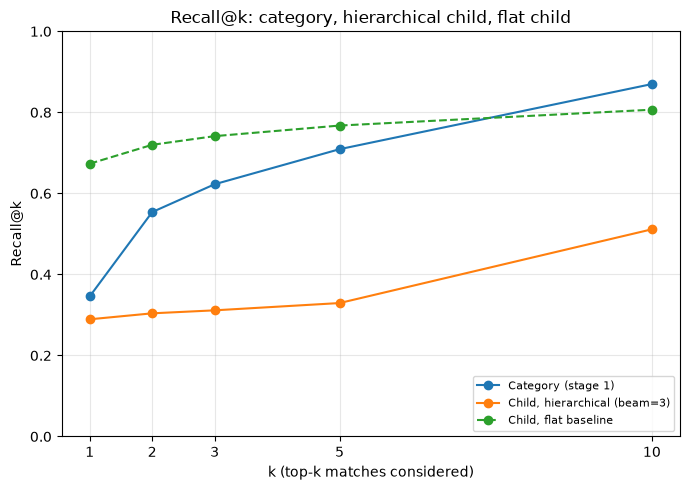

In [22]:
plt.figure(figsize=(7, 5))
plt.plot(ks, cat_recall, marker="o", label="Category (stage 1)")
plt.plot(ks, child_recall, marker="o", label=f"Child, hierarchical (beam={BEAM})")
plt.plot(ks, flat_recall, marker="o", linestyle="--", label="Child, flat baseline")
plt.xticks(ks)
plt.ylim(0, 1)
plt.xlabel("k (top-k matches considered)")
plt.ylabel("Recall@k")
plt.title("Recall@k: category, hierarchical child, flat child")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Child recall@k given the category was found in the beam (isolates stage 2 quality)
in_beam = np.array([
    bool(set(t) & set(p[:BEAM])) for t, p in zip(CVE["true_categories"], CVE["top_categories"])
])
sub = CVE[in_beam]
print(f"Stage 2 child recall@k when the right category was in the beam ({in_beam.sum()} CVEs):")
for k in ks:
    print(f"  Recall@{k}: {recall_at_k(sub['true_children'], sub['top_children'], k):.3f}")
 

Stage 2 child recall@k when the right category was in the beam (16696 CVEs):
  Recall@1: 0.465
  Recall@2: 0.488
  Recall@3: 0.500
  Recall@5: 0.529
  Recall@10: 0.821


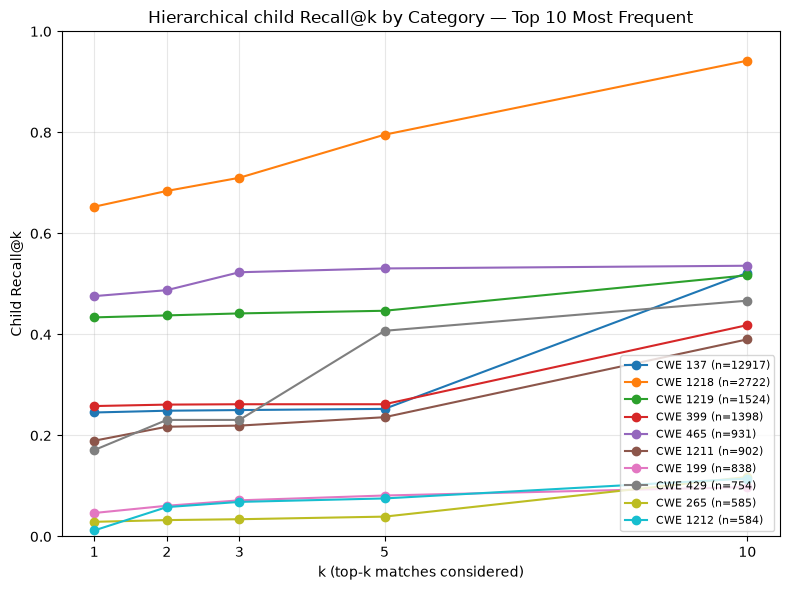

In [24]:
# Per-category child recall@1 / @5 for the 10 most frequent categories
CVE["primary_category"] = CVE["true_categories"].str[0]
top_cats = CVE["primary_category"].value_counts().head(10).index.tolist()
 
plt.figure(figsize=(8, 6))
for cat in top_cats:
    s = CVE[CVE["primary_category"] == cat]
    plt.plot(ks, [recall_at_k(s["true_children"], s["top_children"], k) for k in ks],
             marker="o", label=f"CWE {cat} (n={len(s)})")
plt.xticks(ks)
plt.ylim(0, 1)
plt.xlabel("k (top-k matches considered)")
plt.ylabel("Child Recall@k")
plt.title("Hierarchical child Recall@k by Category — Top 10 Most Frequent")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
def predict(description, beam=BEAM, top_n=5):
    emb = embedding_model.encode([description], convert_to_tensor=True)
    cat_scores = cos_sim(emb, category_embeddings)
    top = hierarchical_search(emb, cat_scores, beam)[0][:top_n]
    best_cat = category_ids[cat_scores.argmax().item()]
    print(f"Top category: CWE-{best_cat} - {graph.nodes[best_cat]['title']}")
    for cid, score in top:
        print(f"  CWE-{cid} ({score:.3f}) - {graph.nodes[cid]['title']}")
 
 
predict("A SQL injection vulnerability allows remote attackers to execute arbitrary queries via the id parameter.")

Top category: CWE-371 - State Issues
  CWE-1265 (0.395) - Unintended Reentrant Invocation of Non-reentrant Code Via Nested Calls
  CWE-374 (0.340) - Passing Mutable Objects to an Untrusted Method
  CWE-15 (0.335) - External Control of System or Configuration Setting
  CWE-375 (0.265) - Returning a Mutable Object to an Untrusted Caller
  CWE-372 (0.173) - Incomplete Internal State Distinction
